In [1]:
import os
from scipy.io import wavfile
import pandas as pd

In [2]:
# Define the root folder containing all subfolders
root_folder = "task1/training"

# Prepare a list to store data
data = []

# Walk through all subfolders and files
for subdir, _, files in os.walk(root_folder):
    for file in files:
        if file.endswith('.wav'):
            filepath = os.path.join(subdir, file)
            sample_rate, audio = wavfile.read(filepath)
            # Store subfolder name for reference
            subfolder = os.path.basename(subdir)
            data.append({
                'filename': file,
                'patient_id': file.split('_')[0],
                'exercise': subfolder,
                'sample_rate': sample_rate,
                'audio': audio
            })

# Create a DataFrame
df = pd.DataFrame(data)

# Show the first few rows
df.head()

,filename,patient_id,exercise,sample_rate,audio
0,ID000_phonationA.wav,ID000,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ID002_phonationA.wav,ID002,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ID003_phonationA.wav,ID003,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [3]:
# Load the Excel file with patient info
excel_path = "task1/sand_task_1.xlsx"
patient_info = pd.read_excel(excel_path, usecols=["ID", "Age", "Sex", "Class"], engine="openpyxl")

# Merge patient info into your main DataFrame
df = df.merge(patient_info, left_on="patient_id", right_on="ID", how="left")

# Drop the redundant 'ID' column if desired
df = df.drop(columns=["ID"])

# Show the updated DataFrame
df.head()

,filename,patient_id,exercise,sample_rate,audio,Age,Sex,Class
0,ID000_phonationA.wav,ID000,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,M,5
1,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",61,F,5
2,ID002_phonationA.wav,ID002,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",51,F,4
3,ID003_phonationA.wav,ID003,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",59,M,3
4,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,F,5


In [4]:
df.describe()

,sample_rate,Age,Class
count,2176.0,2176.000000,2176.000000
mean,8000.0,63.514706,3.926471
std,0.0,11.258949,1.085799
min,8000.0,23.000000,1.000000
25%,8000.0,56.750000,3.000000
50%,8000.0,64.500000,4.000000
75%,8000.0,72.000000,5.000000
max,8000.0,89.000000,5.000000


In [5]:
# Select randomly aproximatley 20% of patient to exclude and save their ids in a excluded_patient_ids.txt file
# N.B. The patients to exclude has to be ideally balanced between classes
# Get unique patients and their class
if False:  # Change to True to run again this block (Already executed once)
    patient_classes = df.groupby('patient_id')['Class'].first().reset_index()

    # Calculate number to exclude per class
    frac = 0.2
    to_exclude = (
        patient_classes.groupby('Class', group_keys=False)
        .apply(lambda x: x.sample(frac=frac, random_state=42))
    )

    excluded_patients = to_exclude['patient_id'].values

    # Save to file
    with open('excluded_patient_ids.txt', 'w') as f:
        for patient_id in excluded_patients:
            f.write(f"{patient_id}\n")

    # Exclude patients from the DataFrame
    df = df[~df['patient_id'].isin(excluded_patients)].reset_index(drop=True)
else:
    with open('excluded_patient_ids.txt', 'r') as f:
        excluded_patients = [line.strip() for line in f]

    # Exclude patients from the DataFrame
    df = df[~df['patient_id'].isin(excluded_patients)].reset_index(drop=True)

In [6]:
df.head()

,filename,patient_id,exercise,sample_rate,audio,Age,Sex,Class
0,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",61,F,5
1,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,F,5
2,ID006_phonationA.wav,ID006,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",73,M,5
3,ID007_phonationA.wav,ID007,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",72,M,3
4,ID009_phonationA.wav,ID009,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",51,F,3


Compute spectrograms and save them to disk

In [7]:
import os
import numpy as np
import librosa
from tqdm import tqdm

# Folder to store precomputed spectrograms
spec_folder = "spectrograms"
os.makedirs(spec_folder, exist_ok=True)

def audio_to_spectrogram(audio, sr, n_mels=128, n_fft=1024, hop_length=512, fmax=512, target_size=(128,128)):
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft,
                                       hop_length=hop_length, fmax=fmax)
    S_db = librosa.power_to_db(S, ref=1.0)
    # Clip & scale to [0,1]
    S_db = np.clip(S_db, -80, 0)
    S_db = (S_db + 80) / 80
    # Resize
    S_db = librosa.util.fix_length(S_db, size=target_size[1], axis=1)
    S_db = librosa.util.fix_length(S_db, size=target_size[0], axis=0)
    return S_db.astype(np.float32)

# Dump spectrograms
for idx, row in tqdm(df.iterrows(), total=len(df)):
    filename = f"{row['patient_id']}_{row['exercise']}.npy"
    path = os.path.join(spec_folder, filename)
    if not os.path.exists(path):
        audio = np.array(row['audio'], dtype=np.float32)
        if audio.max() > 1.0 or audio.min() < -1.0:
            audio /= np.max(np.abs(audio)) + 1e-9
        spec = audio_to_spectrogram(audio, row['sample_rate'], n_mels=128, target_size=(128,128))
        np.save(path, spec)
    df.at[idx, 'spec_path'] = path


100%|██████████| 1752/1752 [00:00<00:00, 4073.61it/s]


Build a tf.data.Dataset to load them efficiently

In [8]:
import tensorflow as tf
import numpy as np

def make_dataset(df, batch_size=16, num_classes=5, shuffle=True, augment=False, class_weights_dict=None):
    """
    Create a tf.data.Dataset with optional oversampling of minority classes
    and data augmentation.
    """

    # --- 1. Compute oversampling indices ---
    if class_weights_dict is not None:
        # Scale weights so majority class has 1.0, others >= 1.0
        max_weight = max(class_weights_dict.values())
        scaled_weights = {k: max_weight / v for k, v in class_weights_dict.items()}
        # Compute repeat factor per sample
        repeat_factors = np.array([scaled_weights[l] for l in df['class_idx']])
        repeat_counts = np.ceil(repeat_factors).astype(int)

        # Build oversampled indices
        oversampled_indices = np.concatenate([
            np.repeat(i, count) for i, count in enumerate(repeat_counts)
        ])
    else:
        oversampled_indices = np.arange(len(df))

    # --- 2. Create dataset ---
    paths = df['spec_path'].values
    labels = df['class_idx'].values

    dataset = tf.data.Dataset.from_tensor_slices((oversampled_indices,))

    def _load_spec(idx):
        idx = idx.numpy()
        path = paths[idx]
        label = labels[idx]

        # Load spectrogram
        spec = np.load(path).astype(np.float32)
        spec = np.expand_dims(spec, -1)  # add channel

        # One-hot encode label
        label_onehot = tf.one_hot(label, depth=num_classes)

        # Sample weight (optional, keep 1.0 if using oversampling)
        weight = 1.0

        # --- Optional augmentation ---
        if augment:
            # Example: add random noise
            spec = spec + 0.01 * np.random.randn(*spec.shape).astype(np.float32)
            spec = np.clip(spec, 0.0, 1.0)
            # TODO: you can add other augmentations here (time shift, freq masking, etc.)

        return spec, label_onehot, weight

    def _load_spec_wrapper(idx):
        spec, label_onehot, weight = tf.py_function(
            _load_spec, [idx], [tf.float32, tf.float32, tf.float32]
        )
        spec.set_shape([128, 128, 1])
        label_onehot.set_shape([num_classes])
        weight.set_shape([])
        return spec, label_onehot, weight

    dataset = dataset.map(_load_spec_wrapper, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(oversampled_indices))

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


Prepare Folds

In [9]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
import numpy as np

# -----------------------------
# Function to get valid folds
# -----------------------------
def make_valid_folds(df, n_splits=5, max_tries=10):
    """
    Create patient-level stratified folds ensuring:
    - All classes appear in both train and val
    - No patient leakage between train/val
    Tries up to `max_tries` different random seeds to find valid folds.
    """
    num_classes = df['class_idx'].nunique()
    folds = []
    tried = 0
    seed = 42

    while len(folds) < n_splits and tried < max_tries:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        tried += 1
        print(f"🔄 Try {tried} with random_state={seed}")

        for fold, (train_idx, val_idx) in enumerate(
            sgkf.split(df, df['class_idx'], groups=df['patient_id'])
        ):
            train_df = df.iloc[train_idx]
            val_df   = df.iloc[val_idx]

            train_classes = set(train_df['class_idx'].unique())
            val_classes   = set(val_df['class_idx'].unique())

            missing_in_val = set(range(num_classes)) - val_classes
            missing_in_train = set(range(num_classes)) - train_classes

            if missing_in_val or missing_in_train:
                print(f"❌ Fold {fold} skipped – "
                      f"Val missing: {missing_in_val}, Train missing: {missing_in_train}")
                continue

            print(f"✅ Fold {fold} OK – all {num_classes} classes present")
            folds.append((train_idx, val_idx))

            if len(folds) == n_splits:
                break  # stop once we have enough

        seed += 1  # try next seed if not enough folds yet

    if len(folds) < n_splits:
        print(f"⚠️ Only {len(folds)} valid folds found after {tried} tries")
    else:
        print(f"🎉 Found {len(folds)} valid folds")

    return folds

In [10]:
# -----------------------------
# Encode labels (make them 0–4 instead of 1–5)
# -----------------------------
label_encoder = LabelEncoder()
df['class_idx'] = label_encoder.fit_transform(df['Class'])
num_classes = df['class_idx'].nunique()

# -----------------------------
# Generate folds
# -----------------------------
folds = make_valid_folds(df, n_splits=5, max_tries=10)

# Use first valid fold
train_idx, val_idx = folds[0]
train_df = df.iloc[train_idx]
val_df   = df.iloc[val_idx]

🔄 Try 1 with random_state=42
❌ Fold 0 skipped – Val missing: {0}, Train missing: set()
✅ Fold 1 OK – all 5 classes present
❌ Fold 2 skipped – Val missing: {0}, Train missing: set()
✅ Fold 3 OK – all 5 classes present
✅ Fold 4 OK – all 5 classes present
🔄 Try 2 with random_state=43
✅ Fold 0 OK – all 5 classes present
❌ Fold 1 skipped – Val missing: {0, 1}, Train missing: set()
✅ Fold 2 OK – all 5 classes present
🎉 Found 5 valid folds


In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights from training DataFrame
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=train_df['class_idx'].values  # <-- use train_df before creating tf.data.Dataset
)

# Convert to dictionary for Keras
class_weights_dict = dict(zip(np.arange(num_classes), class_weights))
print("Class weights:", class_weights_dict)


Class weights: {np.int64(0): np.float64(8.7), np.int64(1): np.float64(1.831578947368421), np.int64(2): np.float64(0.9666666666666667), np.int64(3): np.float64(0.7733333333333333), np.int64(4): np.float64(0.49714285714285716)}


In [12]:
train_ds = make_dataset(train_df, batch_size=16, num_classes=num_classes,
                        shuffle=True, augment=True, class_weights_dict=class_weights_dict)

val_ds = make_dataset(val_df, batch_size=16, num_classes=num_classes,
                      shuffle=False, augment=False, class_weights_dict=None)

print("Train class distribution:", train_df['class_idx'].value_counts().to_dict())
print("Val class distribution:", val_df['class_idx'].value_counts().to_dict())

Train class distribution: {4: 560, 3: 360, 2: 288, 1: 152, 0: 32}
Val class distribution: {3: 128, 4: 128, 2: 80, 1: 16, 0: 8}


Train on the dataset

In [13]:
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np

class F1ScoreCallback(Callback):
    def __init__(self, train_ds, val_ds):
        super().__init__()
        self.train_ds = train_ds
        self.val_ds = val_ds
        self.f1_scores = {"train": [], "val": []}

    def on_epoch_end(self, epoch, logs=None):
        # --- Train ---
        y_true_train, y_pred_train = [], []
        for X_batch, y_batch, sample_weight in self.train_ds:
            preds = self.model.predict(X_batch, verbose=0)
            y_pred_train.extend(np.argmax(preds, axis=1))
            y_true_train.extend(np.argmax(y_batch, axis=1))


        f1_train = f1_score(y_true_train, y_pred_train, average="macro")

        # --- Val ---
        y_true_val, y_pred_val = [], []
        for X_batch, y_batch, sample_weight in self.val_ds:
            preds = self.model.predict(X_batch, verbose=0)
            y_pred_val.extend(np.argmax(preds, axis=1))
            y_true_val.extend(np.argmax(y_batch, axis=1))


        f1_val = f1_score(y_true_val, y_pred_val, average="macro")

        # Save for plotting
        self.f1_scores["train"].append(f1_train)
        self.f1_scores["val"].append(f1_val)

        print(f" — val_f1: {f1_val:.3f} — train_f1: {f1_train:.3f}")


def plot_training_history_with_f1(history, f1_callback):
    hist = history.history

    plt.figure(figsize=(15, 5))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)

    # F1 Score
    plt.subplot(1, 3, 3)
    plt.plot(f1_callback.f1_scores["train"], label="Train F1 (macro)")
    plt.plot(f1_callback.f1_scores["val"], label="Val F1 (macro)")
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.title('F1 Score over Epochs')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [14]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras import layers, regularizers, models

def focal_loss(gamma=2., alpha=.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return loss

def depthwise_separable_block(x, filters, stride=1, dropout=0.2, l2_reg=1e-4):
    # Depthwise conv
    x = layers.DepthwiseConv2D(
        3, strides=stride, padding="same",
        depthwise_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Pointwise conv
    x = layers.Conv2D(
        filters, 1, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Dropout for regularization
    x = layers.Dropout(dropout)(x)
    return x

def build_mobilenet_style(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = depthwise_separable_block(inputs, 32)
    x = depthwise_separable_block(x, 64, stride=2)
    x = depthwise_separable_block(x, 128, stride=2)
    x = depthwise_separable_block(x, 256, stride=2)

    # Global pooling instead of FC layers
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

input_shape = (128, 128, 1)  # freq bins = 128, time frames = 128
model = build_mobilenet_style(input_shape, num_classes)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=focal_loss(),
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# Callbacks
# -----------------------------
f1_callback = F1ScoreCallback(train_ds, val_ds)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    f1_callback
]

# -----------------------------
# Training
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks = callbacks
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 128, 128,  │         10 │ input_layer[0][0] │
│ (DepthwiseConv2D)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │          4 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │         64 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 64, 64,    │        320 │ dropout[0][0]     │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      2,112 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_2  │ (None, 32, 32,    │        640 │ dropout_1[0][0]   │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ depthwise_conv2d

 Total params: 114,899 (448.82 KB)

 Trainable params: 113,489 (443.32 KB)

 Non-trainable params: 1,410 (5.51 KB)

Epoch 1/40
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.5269 - loss: 0.2432 — val_f1: 0.105 — train_f1: 0.145
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 937s 782ms/step - accuracy: 0.5269 - loss: 0.2431 - val_accuracy: 0.3556 - val_loss: 0.2256 - learning_rate: 0.0010
Epoch 2/40
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.5664 - loss: 0.1663 — val_f1: 0.105 — train_f1: 0.145
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 957s 813ms/step - accuracy: 0.5664 - loss: 0.1663 - val_accuracy: 0.3556 - val_loss: 0.2264 - learning_rate: 0.0010
Epoch 3/40
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.5674 - loss: 0.1546 — val_f1: 0.105 — train_f1: 0.145
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 970s 816ms/step - accuracy: 0.5674 - loss: 0.1546 - val_accuracy: 0.3556 - val_loss: 0.2180 - learning_rate: 0.0010
Epoch 4/40
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.5695 - loss: 0.1458 — val_f1: 0.105 — train_f1: 0.145
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 975s 825ms/step - accuracy: 0.56

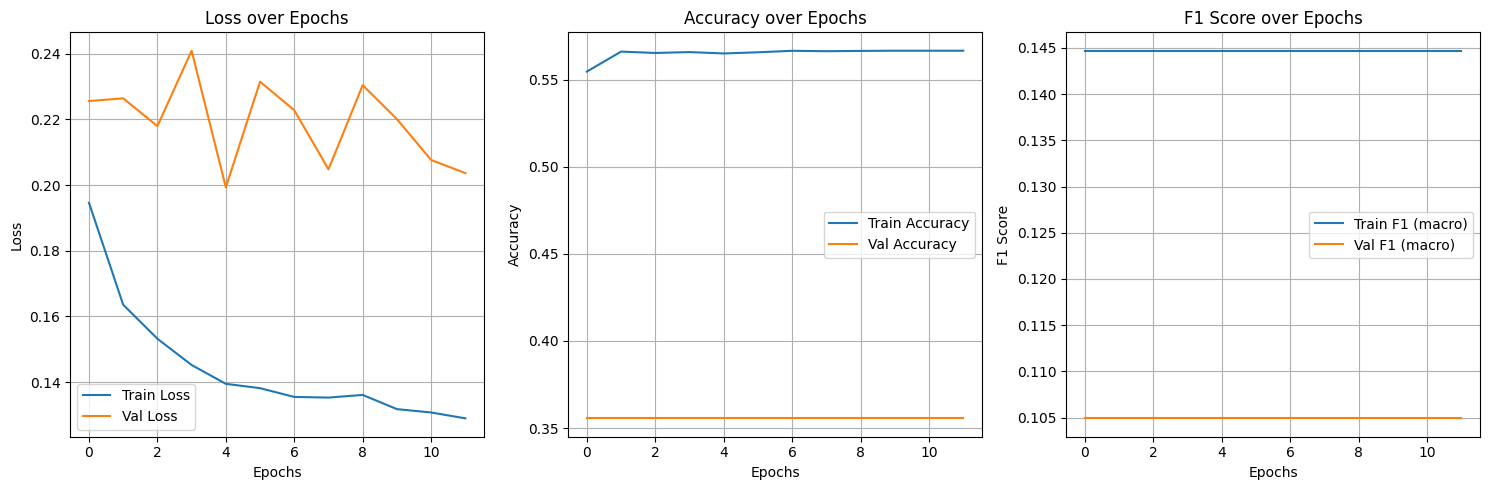

In [15]:
plot_training_history_with_f1(history, f1_callback)

Visualize Confusion MAtrix

In [16]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, dataset, class_names, title="Confusion Matrix"):
    y_true, y_pred = [], []

    for X_batch, y_batch, _ in dataset:
        preds = model.predict(X_batch, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(y_batch.numpy(), axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{title} (Macro F1 = {f1:.3f})")
    plt.show()


In [17]:
# -----------------------------
# Class names (in order of label encoder)
class_names = label_encoder.classes_

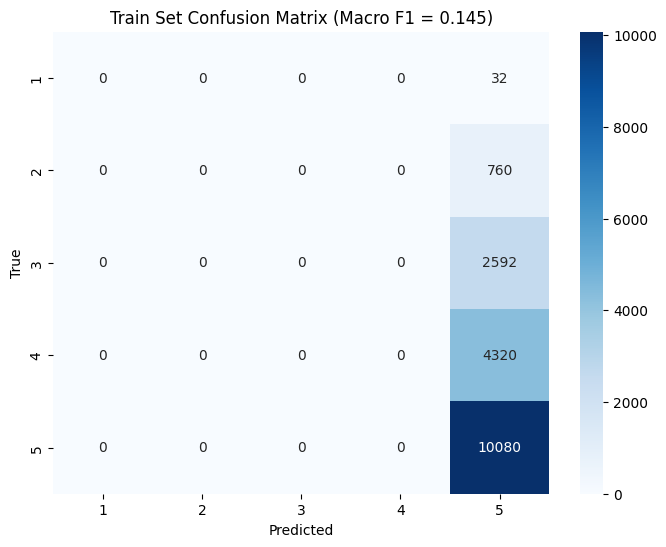

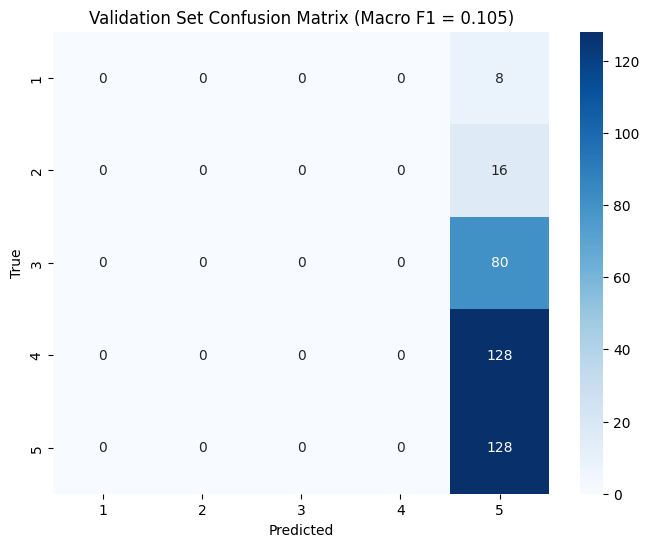

In [18]:
plot_confusion_matrix(model, train_ds, class_names, title="Train Set Confusion Matrix")
plot_confusion_matrix(model, val_ds, class_names, title="Validation Set Confusion Matrix")